In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
tourist_info = pd.read_csv("Data/Japan_grand_total_data.csv")

In [4]:
tourist_info = tourist_info[["Month", "Grand Total", "Year"]]
tourist_info= tourist_info.replace(',','', regex=True)
tourist_info = tourist_info[(tourist_info["Year"].isnull() == False) | (tourist_info["Grand Total"].isnull() == False)]
tourist_info["Year"] = tourist_info["Year"].astype("int64")
tourist_info["Grand Total"] = tourist_info["Grand Total"].astype("int64")
tourist_info.index.name = "t"
tourist_info['Month'] = tourist_info['Month'].str.lstrip()
tourist_info['Month'] = tourist_info['Month'].str[0:3]
tourist_info["Date"] = tourist_info["Month"] + " " + tourist_info["Year"].astype("str")
tourist_info["Date"] = pd.to_datetime(tourist_info["Date"])
tourist_info

,Month,Grand Total,Year,Date
t,,,,
0,Jan,276086,1996,1996-01-01
1,Feb,283667,1996,1996-02-01
2,Mar,310702,1996,1996-03-01
3,Apr,329303,1996,1996-04-01
4,May,326156,1996,1996-05-01
...,...,...,...,...
352,May,3693587,2025,2025-05-01
353,Jun,3377985,2025,2025-06-01
354,Jul,3437118,2025,2025-07-01


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/1434941998.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

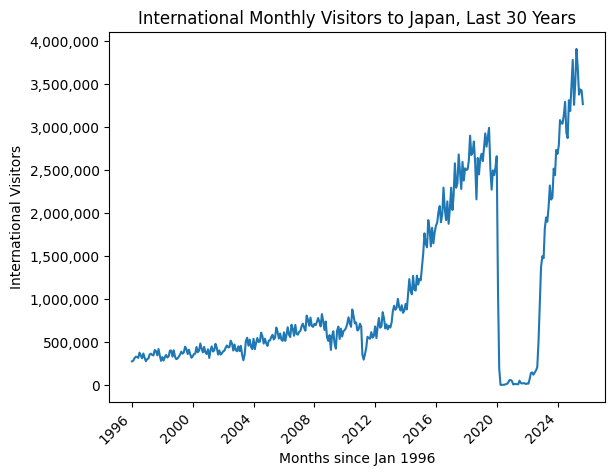

In [5]:
ax = sns.lineplot(data = tourist_info, x= "Date", y = "Grand Total")

ax.set(
    xlabel="Months since Jan 1996",
    ylabel="International Visitors",
    title="International Monthly Visitors to Japan, Last 30 Years"
)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/824772847.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  yearly_tourists = tourist_info.groupby("Year").sum()
/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/824772847.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


[Text(0, -5000000.0, '-5,000,000'),
 Text(0, 0.0, '0'),
 Text(0, 5000000.0, '5,000,000'),
 Text(0, 10000000.0, '10,000,000'),
 Text(0, 15000000.0, '15,000,000'),
 Text(0, 20000000.0, '20,000,000'),
 Text(0, 25000000.0, '25,000,000'),
 Text(0, 30000000.0, '30,000,000'),
 Text(0, 35000000.0, '35,000,000'),
 Text(0, 40000000.0, '40,000,000')]

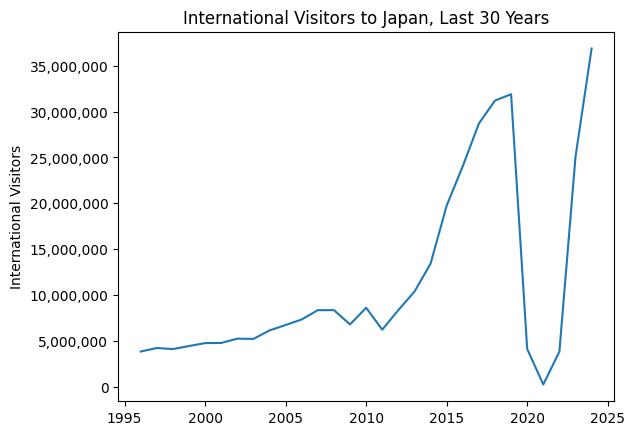

In [6]:
yearly_tourists = tourist_info.groupby("Year").sum()
ax2 = sns.lineplot(data = yearly_tourists[0:-1], x= "Year", y = "Grand Total")
ax2.ticklabel_format(style='plain', axis='y')

ax2.set(
    xlabel="",
    ylabel="International Visitors",
    title="International Visitors to Japan, Last 30 Years"
)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

In [7]:
tourist_pivot = tourist_info.pivot(index = "Year", columns = "Month", values = "Grand Total")

In [8]:
new_order = ['Jan', 'Feb', 'Mar', "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


In [9]:
table3 = tourist_pivot.reindex(new_order, axis=1)

In [10]:
table4 = table3.T

table4

Year,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Month,,,,,,,,,,,,,,,,,,,,,
Jan,276086.0,302148.0,324913.0,308764.0,335621.0,416490.0,392588.0,450847.0,538334.0,516280.0,...,1851895.0,2295668.0,2501409.0,2689339.0,2661022.0,46522.0,17766.0,1497472.0,2688478.0,3781200.0
Feb,283667.0,309318.0,284792.0,330460.0,360621.0,315483.0,400081.0,394869.0,417519.0,519460.0,...,1891375.0,2035771.0,2509297.0,2604322.0,1085147.0,7355.0,16719.0,1475455.0,2788224.0,3258491.0
Mar,310702.0,355228.0,325185.0,353512.0,365689.0,401054.0,434034.0,456614.0,488778.0,557640.0,...,2009550.0,2205664.0,2607956.0,2760136.0,193658.0,12276.0,66121.0,1817616.0,3081781.0,3497600.0
Apr,329303.0,364875.0,349854.0,388777.0,443028.0,449934.0,460377.0,354054.0,546662.0,584406.0,...,2081697.0,2578970.0,2900718.0,2926685.0,2917.0,10853.0,139548.0,1949236.0,3043003.0,3909128.0
May,326156.0,350961.0,320277.0,364474.0,381053.0,390515.0,438537.0,288562.0,500830.0,530752.0,...,1893574.0,2294717.0,2675052.0,2773091.0,1663.0,10035.0,147046.0,1899176.0,3040294.0,3693587.0
Jun,316699.0,345070.0,333460.0,379914.0,400139.0,403477.0,441123.0,352431.0,505003.0,551134.0,...,1985722.0,2346442.0,2704631.0,2880041.0,2565.0,9251.0,120430.0,2073441.0,3140642.0,3377985.0
Jul,377070.0,407510.0,399305.0,446236.0,483849.0,479822.0,516013.0,515692.0,610190.0,669172.0,...,2296451.0,2681518.0,2832040.0,2991189.0,3782.0,51055.0,144578.0,2320694.0,3292602.0,3437118.0
Aug,345020.0,395056.0,401594.0,418094.0,423361.0,433490.0,484771.0,550380.0,567869.0,618655.0,...,2049234.0,2477428.0,2578021.0,2520134.0,8658.0,25916.0,169902.0,2157190.0,2933381.0,3428000.0
Sep,311881.0,345382.0,330401.0,360579.0,379753.0,354578.0,401407.0,457574.0,481570.0,540462.0,...,1918246.0,2280406.0,2159595.0,2272883.0,13684.0,17720.0,206641.0,2184442.0,2872487.0,3266800.0


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/4273276462.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


[Text(0, -500000.0, '-500,000'),
 Text(0, 0.0, '0'),
 Text(0, 500000.0, '500,000'),
 Text(0, 1000000.0, '1,000,000'),
 Text(0, 1500000.0, '1,500,000'),
 Text(0, 2000000.0, '2,000,000'),
 Text(0, 2500000.0, '2,500,000'),
 Text(0, 3000000.0, '3,000,000'),
 Text(0, 3500000.0, '3,500,000'),
 Text(0, 4000000.0, '4,000,000')]

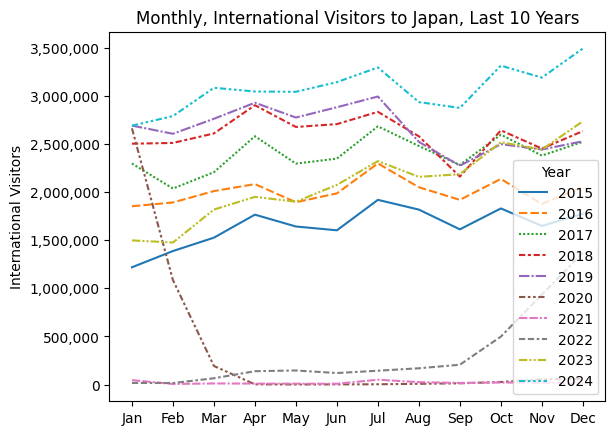

In [11]:
ax3 = sns.lineplot(data = table4.iloc[:, -11:-1])
ax3.ticklabel_format(style='plain', axis='y')


ax3.set(
    xlabel="",
    ylabel="International Visitors",
    title="Monthly, International Visitors to Japan, Last 10 Years"
)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

Because we care about "crowdedness", it would actually be easier to put the data in terms of visitors per day per month rather than simply visitors per month. This is because each month doesn't contain the same number of days. For example, February has 90.3% as many days as January (on non-leap years), which would make February appear to be less crowded. Let's normalize our months. 

In [12]:
import numpy as np
jan = [31] * 30
feb = [29, 28, 28, 28] * 7 + [29, 28]
mar = [31] * 30
apr = [30] * 30
may = [31] * 30
jun = [30] * 30
jul = [31] * 30
aug = [31] * 30
sep = [30] * 30
oct = [31] * 30
nov = [30] * 30
dec = [31] * 30

month_days = pd.DataFrame({'Jan': jan,
              'Feb': feb,
              'Mar': mar,
              'Apr': apr,
              'May': may,
              'Jun': jun,
              'Jul': jul,
              'Aug': aug,
              'Sep': sep,
              'Oct': oct,
              'Nov': nov,
              'Dec': dec})

month_days_final = month_days.T

In [13]:
table4.reset_index(drop = True) 
month_days_final.columns = np.arange(1996, 2026)

avg_daily_arrivals = table4 / month_days_final 

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/935335386.py:11: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


[Text(0, -20000.0, '-20,000'),
 Text(0, 0.0, '0'),
 Text(0, 20000.0, '20,000'),
 Text(0, 40000.0, '40,000'),
 Text(0, 60000.0, '60,000'),
 Text(0, 80000.0, '80,000'),
 Text(0, 100000.0, '100,000'),
 Text(0, 120000.0, '120,000')]

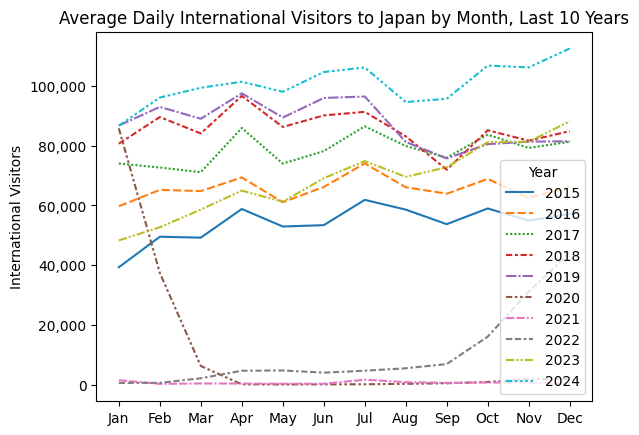

In [14]:
ax3 = sns.lineplot(data = avg_daily_arrivals.iloc[:, -11:-1])
ax3.ticklabel_format(style='plain', axis='y')


ax3.set(
    xlabel="",
    ylabel="International Visitors",
    title="Average Daily International Visitors to Japan by Month, Last 10 Years"
)
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

That's better. Let's now perform classical decomposition. Since the cyclic variation seems to scale as the total number of visitors increases, it would be best if we did multiplicative decomposition. 

In [15]:
tourist_info

,Month,Grand Total,Year,Date
t,,,,
0,Jan,276086,1996,1996-01-01
1,Feb,283667,1996,1996-02-01
2,Mar,310702,1996,1996-03-01
3,Apr,329303,1996,1996-04-01
4,May,326156,1996,1996-05-01
...,...,...,...,...
352,May,3693587,2025,2025-05-01
353,Jun,3377985,2025,2025-06-01
354,Jul,3437118,2025,2025-07-01


In [16]:
# going to put the full time series data in terms of month days
month_days_transed = month_days.iloc[0:1,:].T

In [17]:
month_days_transed.columns = ["Days"]
month_days_transed.index.name = "Month"

In [18]:
merged_months = pd.merge(tourist_info, month_days_transed, on = "Month", how = "left")
merged_months.loc[(merged_months["Year"] % 4 != 0) & (merged_months["Month"] == "Feb"), "Days"] = 28
 

In [19]:
merged_months["Daily_Arrivals"] = merged_months["Grand Total"]/merged_months["Days"]

In [20]:
merged_months.index.name = "t"

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/3578837887.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

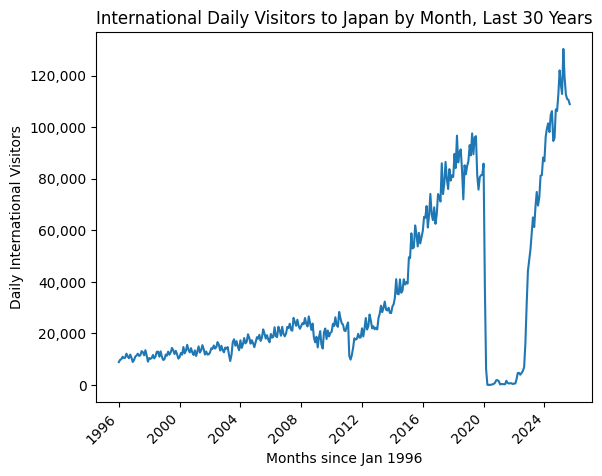

In [21]:
ax = sns.lineplot(data = merged_months, x= "Date", y = "Daily_Arrivals")

ax.set(
    xlabel="Months since Jan 1996",
    ylabel="Daily International Visitors",
    title="International Daily Visitors to Japan by Month, Last 30 Years"
)

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")

Let's get a rolling average on a 2 x 12 cycle. We can use the pandas 'rolling' function.

In [22]:

rolling_2 = merged_months[["Daily_Arrivals"]].rolling(12, center=True).mean()
rolling_2.iloc[0:12,]
rolling_2.index = rolling_2.index - 1
rolling_2.iloc[0:12,]
rolling_3 = rolling_2.rolling(2).mean()
rolling_3.iloc[0:12,]
rolling_3.columns = ["Daily_Arrivals_Moving_Avg"]

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/3276366546.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

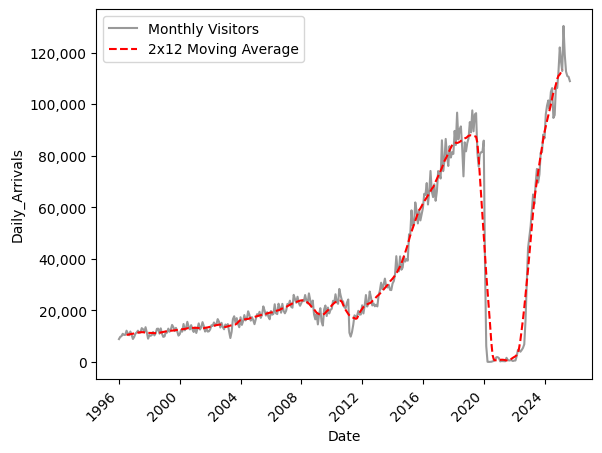

In [24]:
daily_avg = pd.merge(merged_months, rolling_3, on = "t", how = "left")
sns.lineplot(data = daily_avg, x = "Date", y = "Daily_Arrivals", 
             alpha = 0.8, 
             color = "Gray", label = "Monthly Visitors")
sns.lineplot(data = daily_avg, x = "Date", y = "Daily_Arrivals_Moving_Avg", 
             alpha = 1, 
             color = "Red",linestyle = "--", label = "2x12 Moving Average")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")

/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/28170257.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_avg_cut.loc[: ,"detrended"] = daily_avg_cut.loc[:,"Daily_Arrivals"]/daily_avg_cut.loc[:,"Daily_Arrivals_Moving_Avg"]
/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/28170257.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


(array([ 8035.,  9496., 10957., 12418., 13879., 15340., 16801., 18262.,
        19723., 21184.]),
 [Text(8035.0, 0, '1992'),
  Text(9496.0, 0, '1996'),
  Text(10957.0, 0, '2000'),
  Text(12418.0, 0, '2004'),
  Text(13879.0, 0, '2008'),
  Text(15340.0, 0, '2012'),
  Text(16801.0, 0, '2016'),
  Text(18262.0, 0, '2020'),
  Text(19723.0, 0, '2024'),
  Text(21184.0, 0, '2028')])

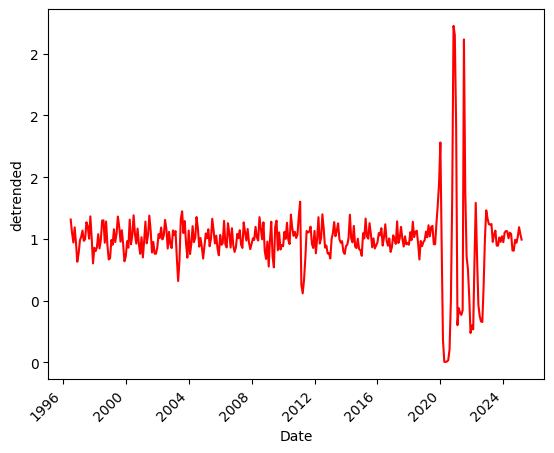

In [25]:
# We can divide this trend line by the detrended average

daily_avg_cut = daily_avg[6:-6]
daily_avg_cut.loc[: ,"detrended"] = daily_avg_cut.loc[:,"Daily_Arrivals"]/daily_avg_cut.loc[:,"Daily_Arrivals_Moving_Avg"]

daily_avg_cut

sns.lineplot(data = daily_avg_cut, x = "Date", y = "detrended", 
             alpha = 1, 
             color = "Red")

current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])
plt.xticks(rotation=45, ha="right")

In [26]:
# Adjusting them so they add to 12
daily_avg_cut["Month_num"] = daily_avg_cut["Date"].dt.month
sum_monthly_trends = daily_avg_cut.groupby("Month_num")["detrended"].mean().sum()

multiplier = 12/sum_monthly_trends
normalized_sum_monthly_trends = multiplier * daily_avg_cut.groupby("Month_num")[["detrended"]].mean()
normalized_sum_monthly_trends.sum()
normalized_sum_monthly_trends


/var/folders/58/r3zgxt3d0g361_lmqmt90gfh0000gn/T/ipykernel_4183/2536329981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_avg_cut["Month_num"] = daily_avg_cut["Date"].dt.month


,detrended
Month_num,
1,1.034132
2,0.968313
3,0.950288
4,1.046738
5,0.909359
6,0.930259
7,1.141960
8,1.021191
9,0.931145


In [27]:
# close enough to 12
seasonal_df = pd.merge(daily_avg_cut, normalized_sum_monthly_trends, on = "Month_num", how = "left")

In [28]:
seasonal_df = seasonal_df.rename(columns = {'detrended_y':'seasonal_component'})
# run below if you need
#seasonal_df.drop(columns = "detrended_x", inplace= True)
seasonal_df

,Month,Grand Total,Year,Date,Days,Daily_Arrivals,Daily_Arrivals_Moving_Avg,detrended_x,Month_num,seasonal_component
0,Jul,377070,1996,1996-07-01,31,12163.548387,10516.635416,1.156601,7,1.141960
1,Aug,345020,1996,1996-08-01,31,11129.677419,10604.392100,1.049535,8,1.021191
2,Sep,311881,1996,1996-09-01,30,10396.033333,10716.965988,0.970054,9,0.931145
3,Oct,366841,1996,1996-10-01,31,11833.580645,10826.218318,1.093048,10,1.055738
4,Nov,316551,1996,1996-11-01,30,10551.700000,10908.963927,0.967250,11,1.021342
...,...,...,...,...,...,...,...,...,...,...
340,Nov,3187175,2024,2024-11-01,30,106239.166667,109752.238178,0.967991,11,1.021342
341,Dec,3489888,2024,2024-12-01,31,112577.032258,110959.963223,1.014573,12,0.989535
342,Jan,3781200,2025,2025-01-01,31,121974.193548,111483.848214,1.094097,1,1.034132
343,Feb,3258491,2025,2025-02-01,28,116374.678571,112342.900634,1.035888,2,0.968313


<AxesSubplot: xlabel='Month', ylabel='seasonal_component'>

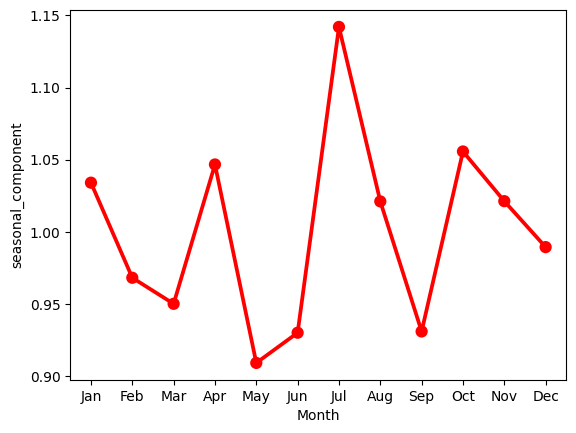

In [29]:
sns.pointplot(data = seasonal_df[6:18], x = 'Month', y = "seasonal_component", 
             color = "Red")



Acording to classical decomposition, May is the least crowded month for tourism while july is the most crowded month for tourism

July is 25.6% more crowded than May on average

In [30]:
seasonal_df["remainder"] = seasonal_df.loc[:,"Daily_Arrivals"]/seasonal_df.loc[:,"seasonal_component"]*seasonal_df.loc[:,"Daily_Arrivals_Moving_Avg"]
seasonal_df

,Month,Grand Total,Year,Date,Days,Daily_Arrivals,Daily_Arrivals_Moving_Avg,detrended_x,Month_num,seasonal_component,remainder
0,Jul,377070,1996,1996-07-01,31,12163.548387,10516.635416,1.156601,7,1.141960,1.120176e+08
1,Aug,345020,1996,1996-08-01,31,11129.677419,10604.392100,1.049535,8,1.021191,1.155743e+08
2,Sep,311881,1996,1996-09-01,30,10396.033333,10716.965988,0.970054,9,0.931145,1.196526e+08
3,Oct,366841,1996,1996-10-01,31,11833.580645,10826.218318,1.093048,10,1.055738,1.213492e+08
4,Nov,316551,1996,1996-11-01,30,10551.700000,10908.963927,0.967250,11,1.021342,1.127028e+08
...,...,...,...,...,...,...,...,...,...,...,...
340,Nov,3187175,2024,2024-11-01,30,106239.166667,109752.238178,0.967991,11,1.021342,1.141634e+10
341,Dec,3489888,2024,2024-12-01,31,112577.032258,110959.963223,1.014573,12,0.989535,1.262366e+10
342,Jan,3781200,2025,2025-01-01,31,121974.193548,111483.848214,1.094097,1,1.034132,1.314934e+10
343,Feb,3258491,2025,2025-02-01,28,116374.678571,112342.900634,1.035888,2,0.968313,1.350170e+10


In [31]:
seasonal_df

,Month,Grand Total,Year,Date,Days,Daily_Arrivals,Daily_Arrivals_Moving_Avg,detrended_x,Month_num,seasonal_component,remainder
0,Jul,377070,1996,1996-07-01,31,12163.548387,10516.635416,1.156601,7,1.141960,1.120176e+08
1,Aug,345020,1996,1996-08-01,31,11129.677419,10604.392100,1.049535,8,1.021191,1.155743e+08
2,Sep,311881,1996,1996-09-01,30,10396.033333,10716.965988,0.970054,9,0.931145,1.196526e+08
3,Oct,366841,1996,1996-10-01,31,11833.580645,10826.218318,1.093048,10,1.055738,1.213492e+08
4,Nov,316551,1996,1996-11-01,30,10551.700000,10908.963927,0.967250,11,1.021342,1.127028e+08
...,...,...,...,...,...,...,...,...,...,...,...
340,Nov,3187175,2024,2024-11-01,30,106239.166667,109752.238178,0.967991,11,1.021342,1.141634e+10
341,Dec,3489888,2024,2024-12-01,31,112577.032258,110959.963223,1.014573,12,0.989535,1.262366e+10
342,Jan,3781200,2025,2025-01-01,31,121974.193548,111483.848214,1.094097,1,1.034132,1.314934e+10
343,Feb,3258491,2025,2025-02-01,28,116374.678571,112342.900634,1.035888,2,0.968313,1.350170e+10


In [34]:
seasonal_df.to_csv("Data/cleaned_df.csv")